In [35]:
import numpy as np

from tools.circuits import generate_steane_circuit
from tools.error_models import construct_bit_flip_model, construct_basic_noise_model, construct_phase_flip_model
from tools.syndrome_prediction import generate_log_error_rates_diff_p, predict_ML, predict_MWPM 
from tools.fssa import compute_critical_exponents, compute_error_bar

In [36]:
import tools.graphics as graphic 
from importlib import reload
reload(graphic)

<module 'tools.graphics' from '/home/leo/Documents/MasterArbeit/code/tools/graphics.py'>

In [37]:
# Global parameters
distances = [5,3,7]
rounds = 1 
noise_set = np.logspace(-3,-0.8, num=10)
num_shots = 1_000 
observable = "X"

steane_circuits = [generate_steane_circuit(d,rounds=rounds,observable=observable) for d in distances]
graphic.save_circuit_diagram(steane_circuits[0],savepath="test_circ.svg")
if observable == "Z":
    error_func = construct_bit_flip_model
    noise_model = "bit_flip"
elif observable == "X":
    error_func = construct_phase_flip_model 
    noise_model = "phase_flip"

In [38]:

# MWMP (Basic Noise)
# count_logical_func = gen_error_model_count_logical_error_MWPM("bit_flip")
count_logical_func = predict_MWPM 


log_error_rates_MWPM, y_errs_MWPM = generate_log_error_rates_diff_p(
    steane_circuits,
    error_func,
    count_log_error_fct=count_logical_func,
    distances= distances,
    noise_set= noise_set,
    num_shots= num_shots,
    rounds=rounds,
    noise_model=noise_model,
    observable=observable
)

       message: Maximum number of function evaluations has been exceeded.
       success: False
        status: 1
           fun: nan
             x: [ 1.000e-01  6.667e-01]
           nit: 100
          nfev: 400
 final_simplex: (array([[ 1.000e-01,  6.667e-01],
                       [ 1.000e-01,  6.667e-01],
                       [ 1.000e-01,  6.667e-01]]), array([       nan,        nan,        nan]))
1.5
0.1


/home/leo/Documents/MasterArbeit/code/tools/fssa.py:19: RuntimeWarning: invalid value encountered in divide
  return ((y1 - y_bar) ** 2) / delta_sq


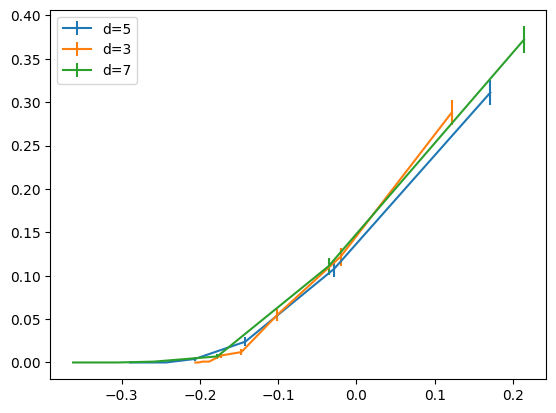

In [39]:
# some tests
xs = [noise_set] * len(distances)
ys = log_error_rates_MWPM 
errs = y_errs_MWPM

guess_pc = 0.1
guess_nu = 1.5 

result = compute_critical_exponents(
    xs_list=xs,
    ys_list=ys,
    errs_list=errs,
    Ls=distances,
    guess_xc=guess_pc,
    guess_nu=guess_nu,
)
print(result)
pc, inv_nu = result.x
nu = 1/inv_nu
print(nu)
print(pc)

graphic.plot_fssa_results(xs,ys,errs,pc,nu,distances)




<Figure size 640x480 with 0 Axes>

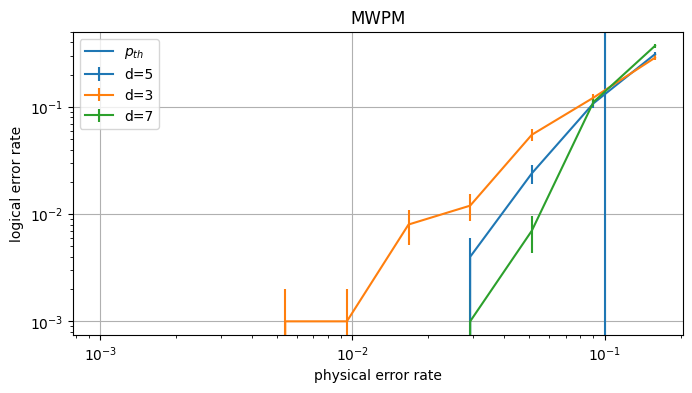

In [40]:

graphic.plot_diff_noise_level(
        log_error_rates_MWPM,
        y_errs_MWPM,
        distances,
        noise_set,
        # fit_slopes = True,
        # reference_lines = True,
        title="MWPM",
        p_th=pc,
    ) 

In [41]:
# ML
count_logical_func = predict_ML

log_error_rates_ML, y_errs_ML = generate_log_error_rates_diff_p(
    steane_circuits,
    error_func,
    count_log_error_fct=count_logical_func,
    distances= distances,
    noise_set= noise_set,
    num_shots= num_shots,
    rounds=rounds,
    noise_model=noise_model,
    observable=observable
)
# Aron
# baseline 52.3s
# 1. improvement: 37.8s  
# 2. improvement: 28.7s jit half syndrome decoder 

       message: Maximum number of function evaluations has been exceeded.
       success: False
        status: 1
           fun: nan
             x: [ 1.000e-01  6.667e-01]
           nit: 100
          nfev: 400
 final_simplex: (array([[ 1.000e-01,  6.667e-01],
                       [ 1.000e-01,  6.667e-01],
                       [ 1.000e-01,  6.667e-01]]), array([       nan,        nan,        nan]))
1.5
0.1


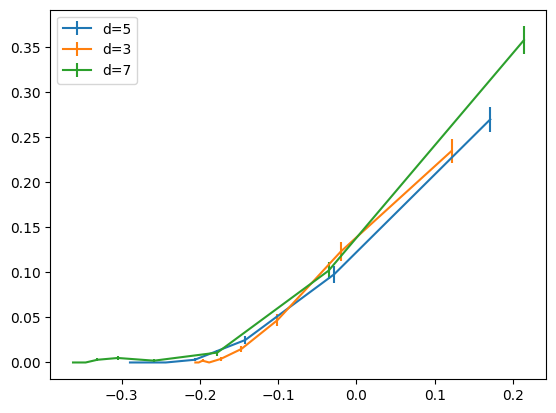

In [42]:
# some tests
xs = [noise_set] * len(distances)
ys = log_error_rates_ML 
errs = y_errs_ML

guess_pc = 0.1
guess_nu = 1.5 

result = compute_critical_exponents(
    xs_list=xs,
    ys_list=ys,
    errs_list=errs,
    Ls=distances,
    guess_xc=guess_pc,
    guess_nu=guess_nu,
)
print(result)
pc, inv_nu = result.x
nu = 1/inv_nu
print(nu)
print(pc)

graphic.plot_fssa_results(xs,ys,errs,pc,nu,distances)

<Figure size 640x480 with 0 Axes>

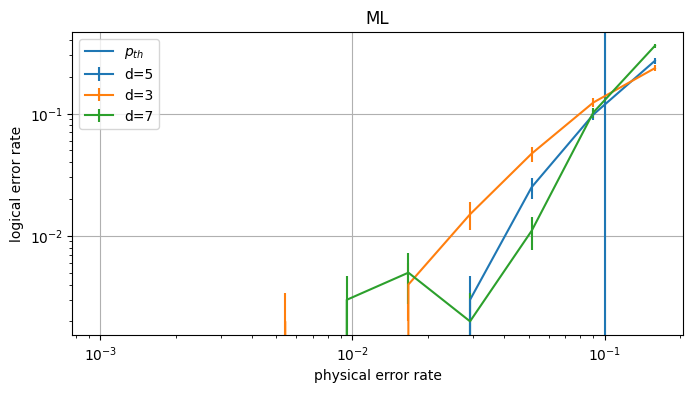

In [43]:
graphic.plot_diff_noise_level(
        log_error_rates_ML,
        y_errs_ML,
        distances,
        noise_set,
        # fit_slopes = True,
        # reference_lines = True,
        title="ML",
        p_th=pc,
    ) 

In [44]:
# # MWPM all knowing using_MWPM 

# # special_circ
# steane_circuits_no_ft = [generate_steane_circuit(d,rounds=rounds,ft_stab_detector=False) for d in distances]


# log_error_rates_MWPM_AK, y_errs_MWPM_AK = generate_log_error_rates_diff_p(
#     steane_circuits_no_ft,
#     error_func,
#     count_log_error_fct=count_logical_func,
#     distances= distances,
#     noise_set= noise_set,
#     num_shots= num_shots,
#     rounds=rounds,
#     noise_model=noise_model,
# )

<Figure size 640x480 with 0 Axes>

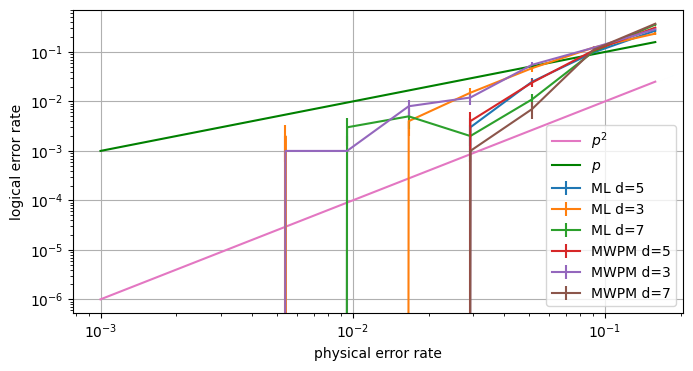

In [45]:
graphic.overlay_different_slopes(
    [log_error_rates_ML, log_error_rates_MWPM, ],
    [y_errs_ML, y_errs_MWPM, ],
    distances=distances,
    noise_set=noise_set,
    titles=["ML", "MWPM", "MWPM (ak)"],
    reference_lines=True,
)

<Figure size 640x480 with 0 Axes>

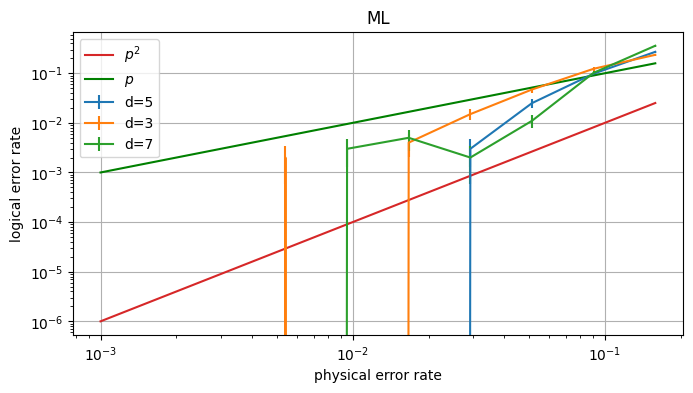

In [46]:
graphic.plot_diff_noise_level(
        log_error_rates_ML,
        y_errs_ML,
        distances,
        noise_set,
        # fit_slopes = True,
        reference_lines = True,
        title="ML"
    ) 
# graphic.plot_diff_noise_level(
#         log_error_rates_MWPM,
#         y_errs_MWPM,
#         distances,
#         noise_set,
#         fit_slopes = True,
#         reference_lines = True,
#         title="MWPM"
#     ) 
# graphic.plot_diff_noise_level(
#         log_error_rates_MWPM_AK,
#         y_errs_MWPM_AK,
#         distances,
#         noise_set,
#         fit_slopes = True,
#         reference_lines = True,
#         title="MWPM AK"
#     ) 